<a href="https://colab.research.google.com/github/nihaar06/RAG/blob/main/Tekworks/RAG_EMP_EMB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

In [2]:
from sentence_transformers import SentenceTransformer
model=SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.


In [3]:
chunk_emb=model.encode(chunks)
print("Embeddings generated successfully.")

Embeddings generated successfully.


In [5]:
print("First Chunk:")
print(chunks[0])
print("="*80)
print("First Chunk Embedding:")
print(chunk_emb[0][:20])

First Chunk:
Employees receive 12 casual leaves annually.
First Chunk Embedding:
[ 0.06183616  0.01376677  0.03366627  0.01861066  0.03135885  0.06788082
 -0.01135733 -0.01733112 -0.07070488  0.01901567  0.10987657  0.0509282
 -0.04896779 -0.04620626 -0.03665624  0.00247604 -0.0628752   0.00541347
  0.03131728 -0.07714855]


In [7]:
print("="*80)
print("Embedding Details")
print("="*80)
print("Number of Chunks:",len(chunks))
print("Embedding Shape:",chunk_emb.shape)

Embedding Details
Number of Chunks: 5
Embedding Shape: (5, 384)


In [9]:
print("\n")
print("="*80)
print("Chunk to vector mapping")
print("="*80)
for i,chunk in enumerate(chunks):
  print(f"Chunk {i+1}:",chunk)
  print("Embedding shape:",chunk_emb[i].shape)
  print("-"*80)



Chunk to vector mapping
Chunk 1: Employees receive 12 casual leaves annually.
Embedding shape: (384,)
--------------------------------------------------------------------------------
Chunk 2: Employees receive 15 sick leaves annually.
Embedding shape: (384,)
--------------------------------------------------------------------------------
Chunk 3: Employees may work from home twice per week.
Embedding shape: (384,)
--------------------------------------------------------------------------------
Chunk 4: Travel expenses are reimbursed within 30 days.
Embedding shape: (384,)
--------------------------------------------------------------------------------
Chunk 5: All employees are covered under company medical insurance.
Embedding shape: (384,)
--------------------------------------------------------------------------------


In [10]:
queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

In [11]:
q=model.encode(queries)
print("Query Embeddings generated successfully.")

Query Embeddings generated successfully.


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
similarities=cosine_similarity(q,chunk_emb)
print("Cosine similarities calculated successfully.")

Cosine similarities calculated successfully.


In [18]:
import numpy as np
similarities

array([[ 0.6551791 ,  0.4110005 ,  0.1762682 ,  0.04933326,  0.04717217],
       [ 0.19633053,  0.22998443,  0.4833979 , -0.02537193,  0.300645  ],
       [ 0.19218388,  0.20799048,  0.08274476,  0.7254896 ,  0.10316081],
       [ 0.265662  ,  0.39323205,  0.3047615 ,  0.14237568,  0.8029629 ]],
      dtype=float32)

In [24]:
np.argmax(similarities[3])

np.int64(4)

### Tasks 5 & 6: Semantic Similarity Analysis and Best Match Identification
We will iterate through each query to find the chunk with the highest cosine similarity score.

In [22]:
import numpy as np

print(f"{'Query':<45} | {'Most Similar Chunk':<60} | {'Score':<5}")
print("-" * 115)

# similarities shape is (len(queries), len(chunks))
for i, query in enumerate(queries):
    # Find index of the highest similarity score for this query
    best_chunk_idx = np.argmax(similarities[i])
    best_score = similarities[i][best_chunk_idx]
    best_chunk_text = chunks[best_chunk_idx]

    print(f"{query[:45]:<45} | {best_chunk_text[:60]:<60} | {best_score:.4f}")

Query                                         | Most Similar Chunk                                           | Score
-------------------------------------------------------------------------------------------------------------------
How many casual leaves are allowed?           | Employees receive 12 casual leaves annually.                 | 0.6552
Can employees work remotely?                  | Employees may work from home twice per week.                 | 0.4834
What is the travel reimbursement process?     | Travel expenses are reimbursed within 30 days.               | 0.7255
Do employees have medical insurance?          | All employees are covered under company medical insurance.   | 0.8030


### Task 7: Similar Meaning vs Different Meaning
We will compare a pair of sentences with almost identical meanings against a pair with completely different topics.

In [25]:
s1 = "Employees receive 12 casual leaves."
s2 = "Workers are entitled to 12 annual leaves."
s3 = "Travel expenses are reimbursed within 30 days."

# Encode the specific sentences
pair_embeddings = model.encode([s1, s2, s3])

sim_pair1 = cosine_similarity([pair_embeddings[0]], [pair_embeddings[1]])[0][0]
sim_pair2 = cosine_similarity([pair_embeddings[0]], [pair_embeddings[2]])[0][0]

print(f"Similarity (Pair 1 - Similar): {sim_pair1:.4f}")
print(f"Similarity (Pair 2 - Different): {sim_pair2:.4f}")

Similarity (Pair 1 - Similar): 0.7710
Similarity (Pair 2 - Different): 0.1750


**Analysis:** Pair 1 has a higher similarity score because words like 'Employees'/'Workers' and 'receive'/'entitled' share semantic space, and the core concept (12 leaves) is identical. Pair 2 has lower similarity because the topics (HR leave policy vs. Finance reimbursement) share very little semantic context.

### Task 8: Embedding Visualization
Since embeddings have hundreds of dimensions, we use PCA (Principal Component Analysis) to project them into 2 dimensions for visualization.

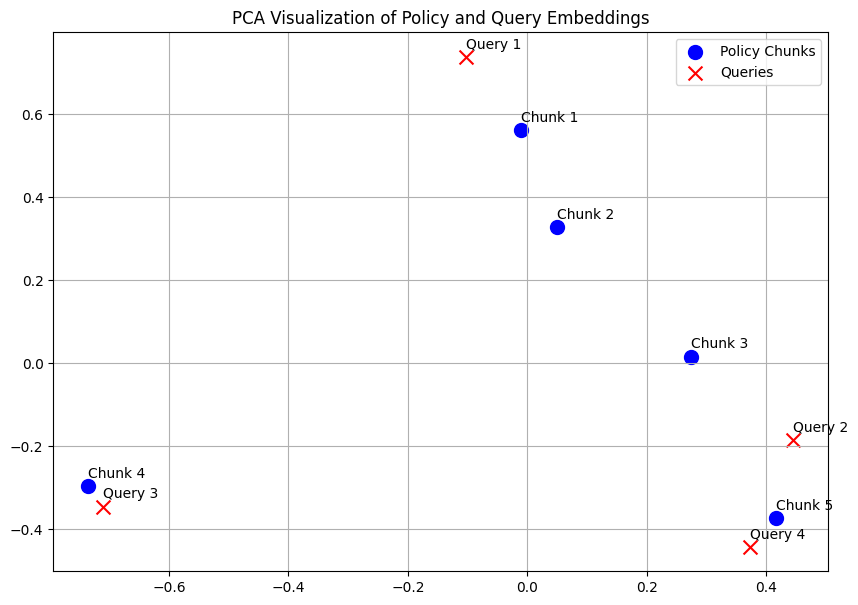

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Combine all embeddings for the plot
all_embeddings = np.vstack([chunk_emb, q])
labels = [f"Chunk {i+1}" for i in range(len(chunks))] + [f"Query {i+1}" for i in range(len(queries))]

# Reduce dimensions to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(all_embeddings)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(coords[:len(chunks), 0], coords[:len(chunks), 1], c='blue', label='Policy Chunks', s=100)
plt.scatter(coords[len(chunks):, 0], coords[len(chunks):, 1], c='red', label='Queries', marker='x', s=100)

# Annotate points
for i, label in enumerate(labels):
    plt.annotate(label, (coords[i, 0], coords[i, 1] + 0.02))

plt.title("PCA Visualization of Policy and Query Embeddings")
plt.legend()
plt.grid(True)
plt.show()

**Visualization Analysis:** In the plot above, semantically similar texts (like Query 1 and Chunk 1) will appear closer to each other. This is because the embedding model maps similar concepts to nearby vectors in the high-dimensional space, and PCA preserves as much of that spatial relationship as possible in 2D.